In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from collections.abc import Iterable
from matplotlib.lines import Line2D
from typing import Literal
import numpy as np

from misophonia_dataset.interface import get_data_dir

from misophonia_anc._mlflow_stats import (
    get_mlflow_metric_history,
    auto_combine_mean_with_std,
    RUN_INDEX,
)

/build/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Config
figs_dir = get_data_dir(dataset_name="report_figs")

GLOBAL_SI_SNR_RANGE = (0, 3.5)

In [13]:
get_mlflow_metric_history(
    ("model-baseline-rep1", "model-baseline-rep2"),
    (
        "val/epoch/si_snr_improvement",
        "train/epoch/loss",
    ),
)

,run_name,step,timestamp,val/epoch/si_snr_improvement,train/epoch/loss,pretty_name
0,model-baseline-rep1,1,1777840596508,0.683738,-7.233837,Baseline
1,model-baseline-rep1,2,1777841952199,1.134515,-8.367071,Baseline
2,model-baseline-rep1,3,1777843307621,1.435146,-8.694747,Baseline
3,model-baseline-rep1,4,1777844657384,1.431057,-8.890339,Baseline
4,model-baseline-rep1,5,1777846007626,1.614060,-9.033155,Baseline
...,...,...,...,...,...,...
155,model-baseline-rep2,76,1777774004287,2.263224,-12.344591,Baseline (rep. 2)
156,model-baseline-rep2,77,1777775557581,2.296484,-12.330220,Baseline (rep. 2)
157,model-baseline-rep2,78,1777777106462,2.012222,-12.402681,Baseline (rep. 2)
158,model-baseline-rep2,79,1777778657748,2.313993,-12.346035,Baseline (rep. 2)


In [14]:
auto_combine_mean_with_std(
    ("model-baseline-rep1", "model-baseline-rep2", "model-baseline-rep3"),
    "val/epoch/si_snr_improvement",
)

,run_name,step,timestamp,val/epoch/si_snr_improvement,val/epoch/si_snr_improvement_std,pretty_name
0,model-baseline-rep1,1,1777840596508,0.683738,1.308915,Baseline
1,model-baseline-rep1,2,1777841952199,1.134515,1.681772,Baseline
2,model-baseline-rep1,3,1777843307621,1.435146,2.160516,Baseline
3,model-baseline-rep1,4,1777844657384,1.431057,2.008114,Baseline
4,model-baseline-rep1,5,1777846007626,1.614060,2.509831,Baseline
...,...,...,...,...,...,...
235,model-baseline-rep3,76,1777795260550,2.564213,4.815880,Baseline (rep. 3)
236,model-baseline-rep3,77,1777796605285,2.467254,4.955320,Baseline (rep. 3)
237,model-baseline-rep3,78,1777881348666,2.316607,4.973790,Baseline (rep. 3)
238,model-baseline-rep3,79,1777882691665,2.283842,4.886770,Baseline (rep. 3)


In [7]:
def pretty_count(x: float, pos: int | None = None) -> str:
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:g}M"
    if abs(x) >= 1_000:
        return f"{x / 1_000:g}k"
    return f"{x:g}"

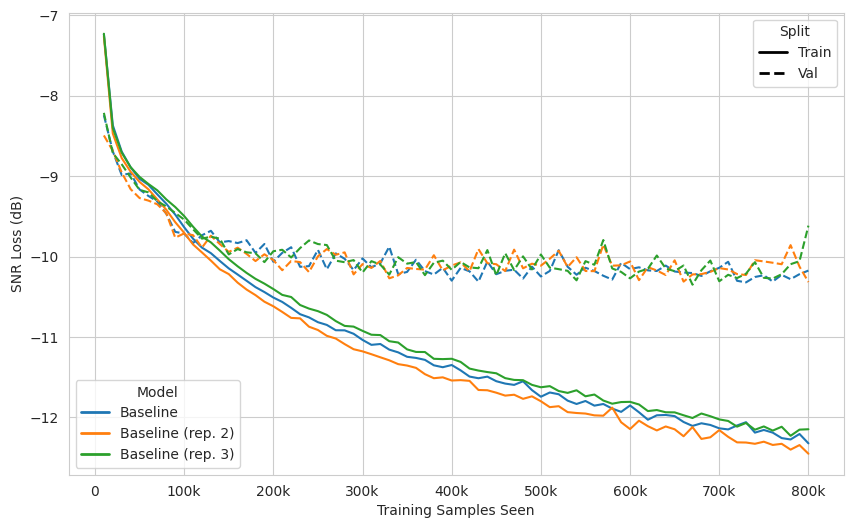

In [8]:
def val_vs_train_loss(
    data: pd.DataFrame,
    val_col: str = "val/epoch/loss",
    train_col: str = "train/epoch/loss",
    *,
    metric_name: str = "SNR Loss (dB)",
    title: str | None = None,
    save_to: Path | None = None,
    y_range: tuple[float, float] | None = None,
) -> None:

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))

    if not isinstance(data["run_name"].dtype, pd.CategoricalDtype):
        data = data.copy()
        data["run_name"] = data["run_name"].astype("category")

    colors = sns.color_palette("tab10", n_colors=data["run_name"].nunique())

    model_handles = []

    for i, (run_name, group) in enumerate(data.groupby("run_name", observed=True)):
        group = group.copy().sort_values("step")

        pretty_name = group["pretty_name"].iloc[0]
        train_size = RUN_INDEX.get(run_name, {}).get("train_size", 10_000)
        train_size_per_epoch = RUN_INDEX.get(run_name, {}).get("train_size_per_epoch", train_size)
        group["train_samples_seen"] = group["step"] * train_size_per_epoch

        color = colors[i]

        ax.plot(
            group["train_samples_seen"],
            group[val_col],
            color=color,
            linestyle="--",
            label="_nolegend_",
        )
        ax.plot(
            group["train_samples_seen"],
            group[train_col],
            color=color,
            linestyle="-",
            label="_nolegend_",
        )

        model_handles.append(Line2D([0], [0], color=color, lw=2, label=pretty_name))

    split_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="Train"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Val"),
    ]

    legend1 = ax.legend(
        handles=split_handles,
        title="Split",
        loc="upper right",
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=model_handles,
        title="Model",
        loc="lower left",
    )

    if title is not None:
        ax.set_title(title)
    ax.set_xlabel("Training Samples Seen")
    ax.set_ylabel(metric_name)

    if y_range is not None:
        ax.set_ylim(y_range)

    ax.xaxis.set_major_formatter(FuncFormatter(pretty_count))

    if save_to is not None:
        save_to.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")

    plt.show()


val_vs_train_loss(
    get_mlflow_metric_history(
        (
            "model-baseline-rep1",
            "model-baseline-rep2",
            "model-baseline-rep3",
        ),
        (
            "val/epoch/loss",
            "train/epoch/loss",
        ),
    ),
    save_to=figs_dir / "baseline_loss_train_val.pdf",
)

In [5]:
def plot_metric(
    data: pd.DataFrame,
    mean_col: str,
    *,
    metric_name: str = "Metric",
    title: str | None = None,
    std_label: str = "Std Dev",
    std_col: str | Iterable[str] | None = None,
    save_to: Path | None = None,
    y_range: tuple[float, float] | None = None,
    include_best_star: Literal["low", "high"] | None = "high",
) -> None:
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    for run_name, group in data.groupby("run_name", observed=True):
        # make step = number of training samples seens (using run_index.train_size_per_epoch)
        # Get first pretty name of group
        pretty_name = group["pretty_name"].iloc[0]
        train_size = RUN_INDEX.get(run_name, {}).get("train_size", 10_000)
        train_size_per_epoch = RUN_INDEX.get(run_name, {}).get("train_size_per_epoch", train_size)
        group["train_samples_seen"] = group["step"] * train_size_per_epoch

        # group = group.copy().sort_values("train_samples_seen")

        line = sns.lineplot(data=group, x="train_samples_seen", y=mean_col, label=pretty_name)

        model_color = line.lines[-1].get_color()

        if include_best_star is not None:
            if include_best_star == "high":
                best_idx = group[mean_col].idxmax()
            elif include_best_star == "low":
                best_idx = group[mean_col].idxmin()
            else:
                raise ValueError("include_best_star must be one of: None, 'low', 'high'")

            best_row = group.loc[best_idx]

            plt.scatter(
                best_row["train_samples_seen"],
                best_row[mean_col],
                marker="*",
                s=120,
                color=model_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=10,
            )

        if std_col is not None:
            plt.fill_between(
                group["train_samples_seen"],
                group[mean_col] - group[std_col],
                group[mean_col] + group[std_col],
                alpha=0.3,
                label=std_label,
            )

    if title is not None:
        plt.title(title)
    plt.xlabel("Training Samples Seen")
    plt.ylabel(metric_name)

    if y_range is not None:
        plt.ylim(y_range)

    plt.gca().xaxis.set_major_formatter(FuncFormatter(pretty_count))

    # Legend
    handles, labels = plt.gca().get_legend_handles_labels()

    if include_best_star is not None:
        handles.append(
            Line2D(
                [0],
                [0],
                marker="*",
                color="black",
                linestyle="None",
                markersize=10,
                label="Best",
            )
        )
        labels.append("Best")

    plt.legend(handles=handles, labels=labels)

    if save_to is not None:
        save_to.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_to, bbox_inches="tight")

    plt.show()

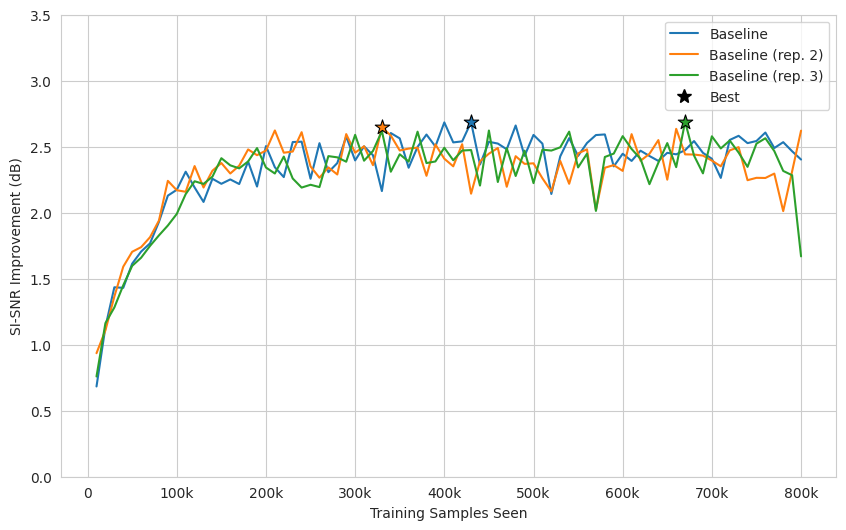

In [62]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-baseline-rep2",
            "model-baseline-rep3",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    save_to=figs_dir / "baseline_val_si_snri.pdf",
    y_range=GLOBAL_SI_SNR_RANGE,
    # std_col="val/epoch/si_snr_improvement_std",
)

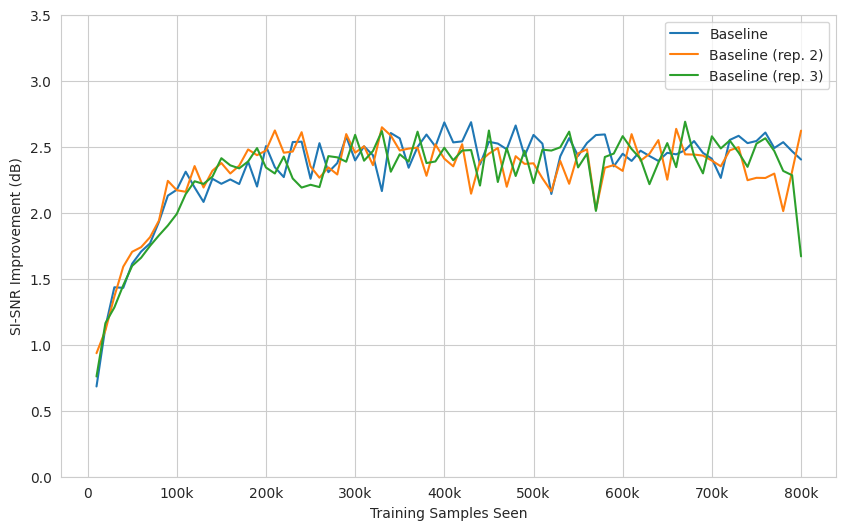

In [10]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-baseline-rep2",
            "model-baseline-rep3",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    save_to=figs_dir / "baseline_val.pdf",
    y_range=GLOBAL_SI_SNR_RANGE,
    # std_col="val/epoch/si_snr_improvement_std",
)

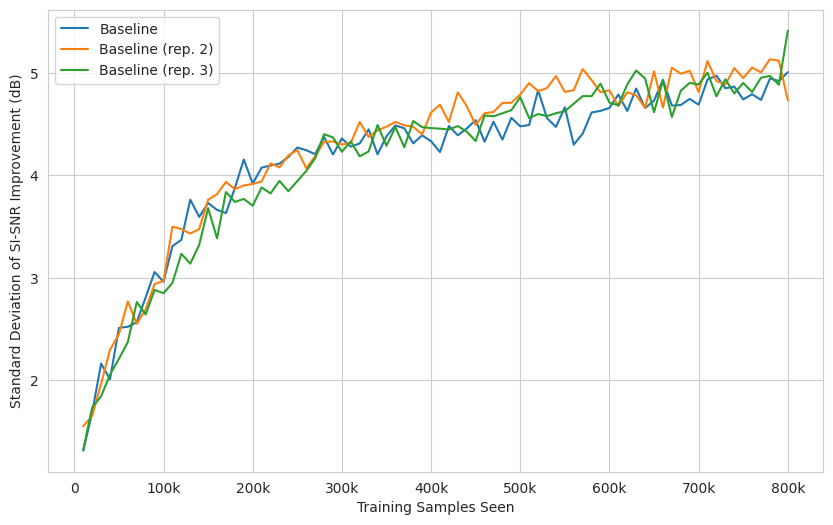

In [11]:
plot_metric(
    get_mlflow_metric_history(
        (
            "model-baseline-rep1",
            "model-baseline-rep2",
            "model-baseline-rep3",
        ),
        "val/epoch/si_snr_improvement_std",
    ),
    "val/epoch/si_snr_improvement_std",
    metric_name="Standard Deviation of SI-SNR Improvement (dB)",
)

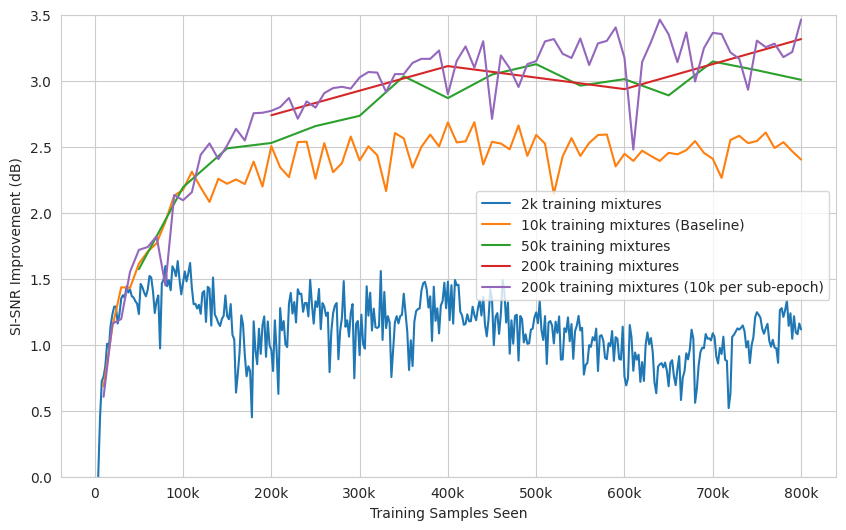

In [12]:
size_data = auto_combine_mean_with_std(
    (
        "model-size-2k",
        "model-baseline-rep1",
        "model-size-50k",
        "model-size-200k",
        "model-size-10k-of-200k",
    ),
    "val/epoch/si_snr_improvement",
)
# Remove step > 4 from model-size-200k (to keep it on the same scale)
size_data = size_data[~((size_data["run_name"] == "model-size-200k") & (size_data["step"] > 4))]

# Change pretty name of baseline to "Baseline (10k)"
size_data.loc[size_data["run_name"] == "model-baseline-rep1", "pretty_name"] = "10k training mixtures (Baseline)"

plot_metric(
    size_data,
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    save_to=figs_dir / "training_size_effect.pdf",
    y_range=GLOBAL_SI_SNR_RANGE,
    # std_col="val/epoch/si_snr_improvement_std",
)

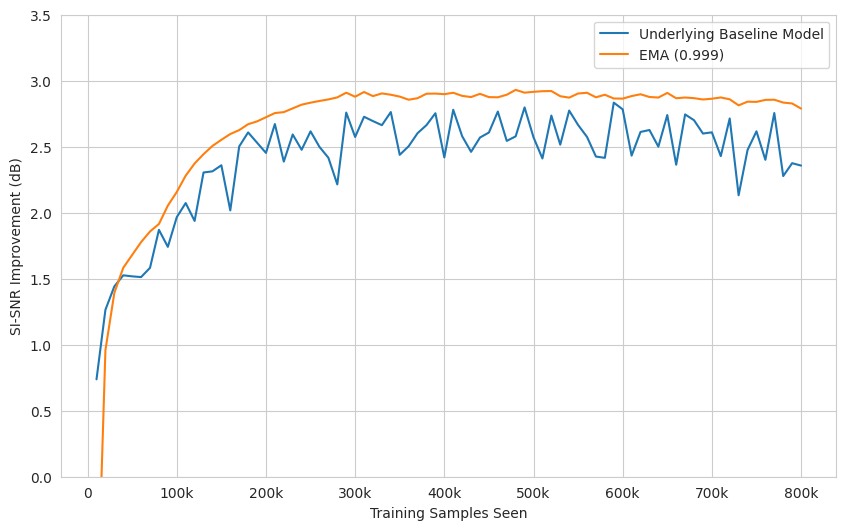

In [ ]:
# Append the "ema/val/epoch/si_snr_improvement" column as new rows instead, adding them to the same "val/epoch/si_snr_improvement" column, and set the "pretty_name" to "EMA (0.999)" and "run_name" to "model-ema-0.999-ema"


def _prepare_ema_data():
    ema_099_data = get_mlflow_metric_history(
        "model-ema-0.999",
        ("val/epoch/si_snr_improvement", "ema/val/epoch/si_snr_improvement"),
    )
    ema_col_data = ema_099_data[["step", "ema/val/epoch/si_snr_improvement"]].copy()
    ema_col_data["run_name"] = "model-ema-0.999-ema"
    ema_col_data["pretty_name"] = "EMA (0.999)"
    ema_col_data.rename(columns={"ema/val/epoch/si_snr_improvement": "val/epoch/si_snr_improvement"}, inplace=True)

    normal_col_data = ema_099_data[["step", "val/epoch/si_snr_improvement"]].copy()
    normal_col_data["run_name"] = "model-ema-0.999"
    normal_col_data["pretty_name"] = "Underlying Baseline Model"

    return pd.concat([normal_col_data, ema_col_data], ignore_index=True)


plot_metric(
    _prepare_ema_data(),
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    save_to=figs_dir / "ema_effect.pdf",
    y_range=GLOBAL_SI_SNR_RANGE,
)

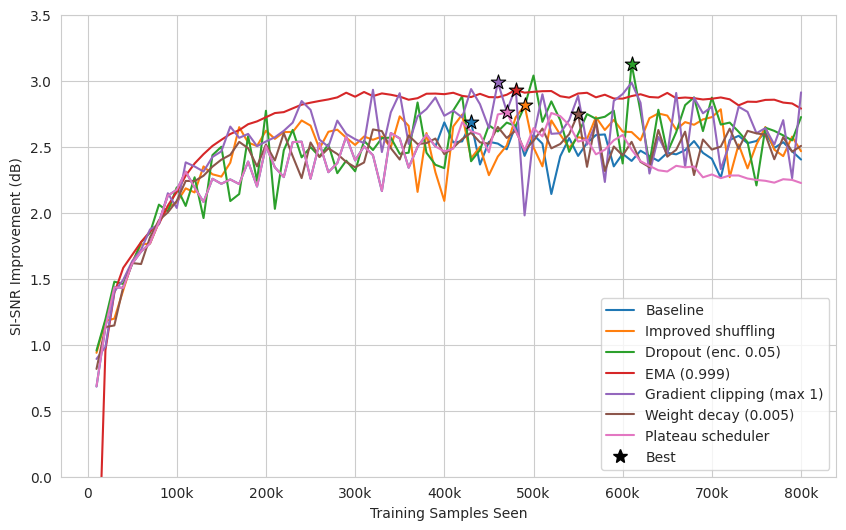

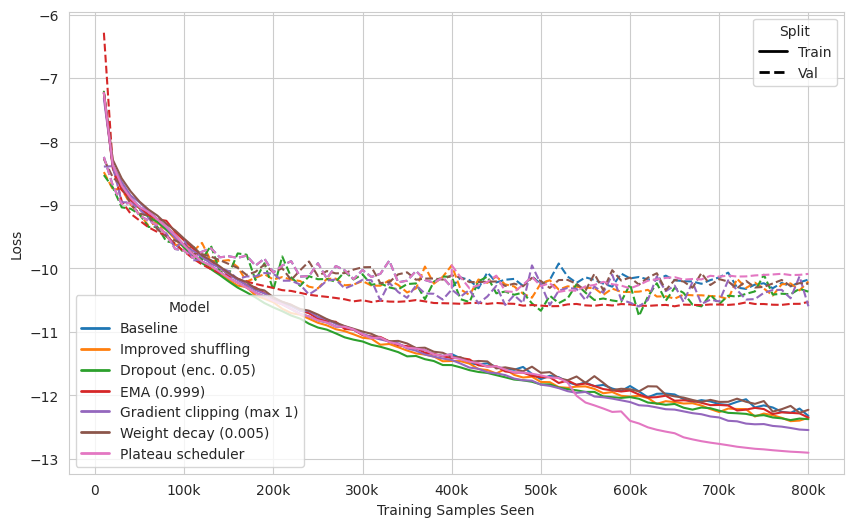

In [ ]:
def _make_optim_graph():
    ema_data = get_mlflow_metric_history(
        "model-ema-0.999", ("ema/val/epoch/si_snr_improvement", "ema/val/epoch/loss", "train/epoch/loss")
    )
    ema_data = ema_data.rename(
        columns={
            "ema/val/epoch/si_snr_improvement": "val/epoch/si_snr_improvement",
            "ema/val/epoch/loss": "val/epoch/loss",
        }
    )
    ema_data["run_name"] = "model-ema-0.999-ema"
    ema_data["pretty_name"] = "EMA (0.999)"

    baseline_data = get_mlflow_metric_history(
        "model-baseline-rep1", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )

    plateau_data = get_mlflow_metric_history(
        "model-lr-half-on-5plateau-after-40", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )
    plateau_data = pd.concat([baseline_data[baseline_data["step"] <= 40].copy(), plateau_data], ignore_index=True)
    plateau_data["run_name"] = "model-lr-half-on-5plateau-after-40"
    plateau_data["pretty_name"] = "Plateau scheduler"

    bettershuffle_data = get_mlflow_metric_history(
        "model-bettershuffle", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )

    wd_data = get_mlflow_metric_history(
        "model-lr-0.0005-wd-0.005", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )

    gradclip_1_data = get_mlflow_metric_history(
        "model-gradclip-1", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )

    enc_dropout_data = get_mlflow_metric_history(
        "model-dropout-enc-0.05", ("val/epoch/si_snr_improvement", "val/epoch/loss", "train/epoch/loss")
    )

    data = pd.concat(
        [baseline_data, ema_data, plateau_data, bettershuffle_data, wd_data, gradclip_1_data, enc_dropout_data],
        ignore_index=True,
    )

    plot_metric(
        data,
        "val/epoch/si_snr_improvement",
        metric_name="SI-SNR Improvement (dB)",
        save_to=figs_dir / "optim_effect_si_snri.pdf",
        y_range=GLOBAL_SI_SNR_RANGE,
    )

    val_vs_train_loss(
        data,
        val_col="val/epoch/loss",
        train_col="train/epoch/loss",
        metric_name="Loss",
        save_to=figs_dir / "optim_effect_loss.pdf",
    )


_make_optim_graph()

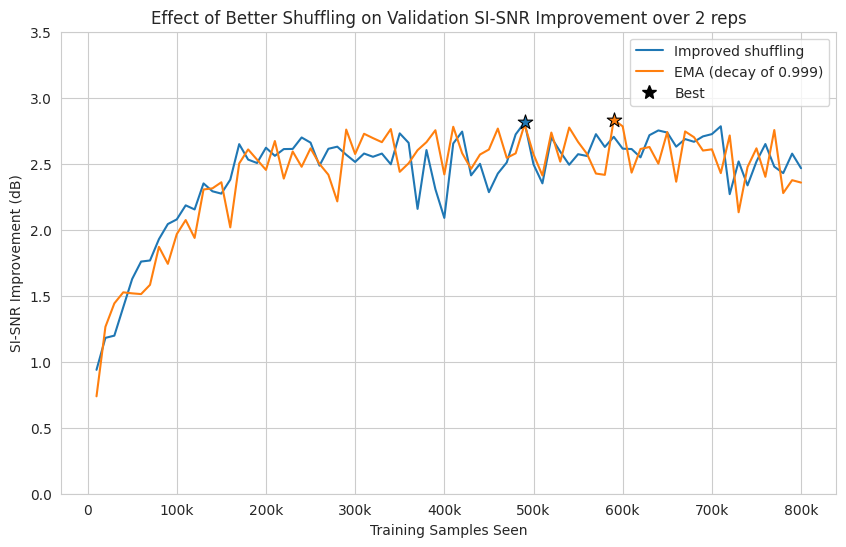

In [ ]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-bettershuffle",
            "model-ema-0.999",  # This is the same as the bettershuffle, just with EMA active at the same time
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    title="Effect of Better Shuffling on Validation SI-SNR Improvement over 2 reps",
    y_range=GLOBAL_SI_SNR_RANGE,
    metric_name="SI-SNR Improvement (dB)",
)

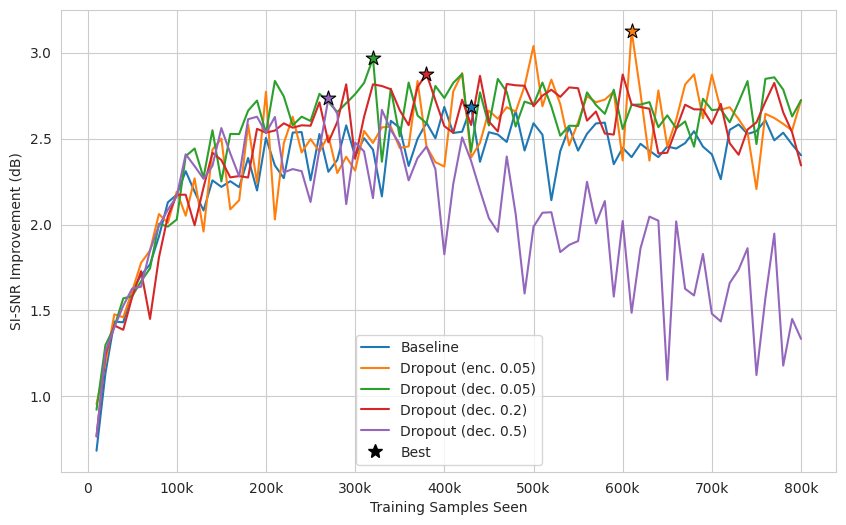

In [70]:
plot_metric(
    auto_combine_mean_with_std(
        (
            "model-baseline-rep1",
            "model-dropout-enc-0.05",
            "model-dropout-dec-0.05",
            "model-dropout-dec-0.2",
            "model-dropout-dec-0.5",
        ),
        "val/epoch/si_snr_improvement",
    ),
    "val/epoch/si_snr_improvement",
    metric_name="SI-SNR Improvement (dB)",
    # std_col="val/epoch/si_snr_improvement_std",
)

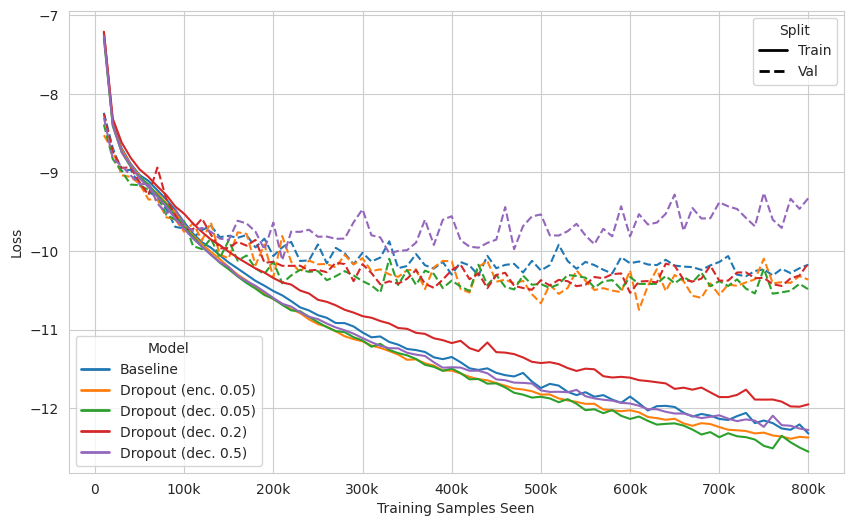

In [69]:
val_vs_train_loss(
    get_mlflow_metric_history(
        (
            "model-baseline-rep1",
            "model-dropout-enc-0.05",
            "model-dropout-dec-0.05",
            "model-dropout-dec-0.2",
            "model-dropout-dec-0.5",
        ),
        (
            "val/epoch/loss",
            "train/epoch/loss",
        ),
    ),
    val_col="val/epoch/loss",
    train_col="train/epoch/loss",
    metric_name="Loss",
)


,step,val/epoch/si_snr_improvement,run_name,pretty_name,timestamp
0,1,4.571379,their_model,Their Model (until best epoch),NaN
1,2,5.831573,their_model,Their Model (until best epoch),NaN
2,3,5.974886,their_model,Their Model (until best epoch),NaN
3,4,6.434665,their_model,Their Model (until best epoch),NaN
4,5,7.125927,their_model,Their Model (until best epoch),NaN
...,...,...,...,...,...
318,319,2.145490,model-baseline-rep3,Our Baseline (400 epochs),1.778516e+12
319,320,2.335260,model-baseline-rep3,Our Baseline (400 epochs),1.778518e+12
320,321,2.468579,model-baseline-rep3,Our Baseline (400 epochs),1.778519e+12
321,322,2.155301,model-baseline-rep3,Our Baseline (400 epochs),1.778521e+12


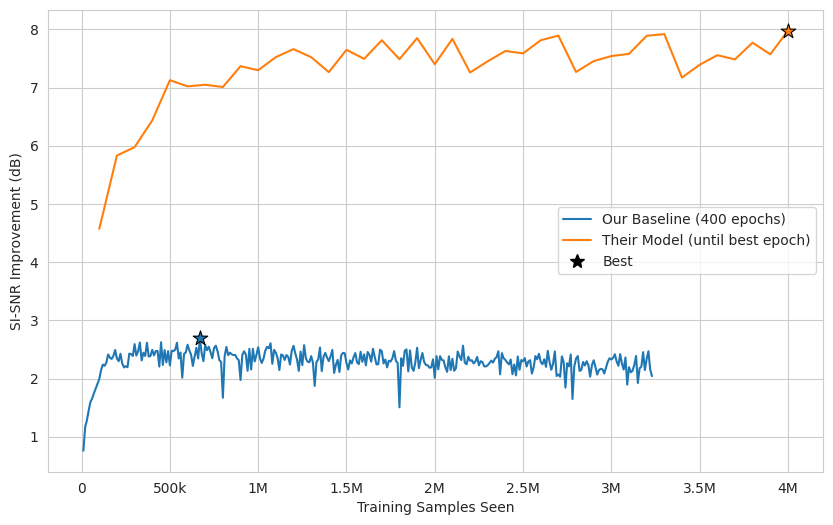

In [15]:
def _their_vs_ours():
    their_si_snri = np.array([4.57137882, 5.83157331, 5.97488623, 6.43466499, 7.12592667,
       7.02005105, 7.04716576, 7.00862066, 7.36620507, 7.29740821,
       7.52253984, 7.65990274, 7.52206932, 7.26396807, 7.64763209,
       7.49230811, 7.8127809 , 7.48675517, 7.84903163, 7.40037929,
       7.83540438, 7.25807065, 7.45066995, 7.62779623, 7.58601458,
       7.81195241, 7.89198796, 7.26751966, 7.45302494, 7.54040152,
       7.57763158, 7.88835185, 7.91732641, 7.17091929, 7.39050593,
       7.55531674, 7.483288  , 7.77081657, 7.57037277, 7.97578196])
    their_data = pd.DataFrame({
        "step": np.arange(1, len(their_si_snri)+1),
        "val/epoch/si_snr_improvement": their_si_snri,
        "run_name": "their_model",
        "pretty_name": "Their Model (until best epoch)",
    })

    our_baseline_si_snr = get_mlflow_metric_history(
        ("model-baseline-rep3",
         "model-baseline-rep3-400epochs"),
        "val/epoch/si_snr_improvement",
    )
    # Rename model-baseline-rep3-400epochs
    our_baseline_si_snr["run_name"] = "model-baseline-rep3"
    our_baseline_si_snr["pretty_name"] = "Our Baseline (400 epochs)"

    # Combine both
    data = pd.concat([their_data, our_baseline_si_snr])

    include_best_star = True
    mean_col = "val/epoch/si_snr_improvement"

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    display(data)

    for run_name, group in data.groupby("run_name", observed=True):
        # make step = number of training samples seens (using run_index.train_size_per_epoch)
        # Get first pretty name of group
        pretty_name = group["pretty_name"].iloc[0]
        if run_name == "their_model":
            train_size_per_epoch = 100_000
        else:
            train_size = RUN_INDEX.get(run_name, {}).get("train_size", 10_000)
            train_size_per_epoch = RUN_INDEX.get(run_name, {}).get("train_size_per_epoch", train_size)
        
        group["train_samples_seen"] = group["step"] * train_size_per_epoch

        line = sns.lineplot(data=group, x="train_samples_seen", y=mean_col, label=pretty_name)

        model_color = line.lines[-1].get_color()

        best_idx = group[mean_col].idxmax()

        best_row = group.loc[best_idx]

        plt.scatter(
            best_row["train_samples_seen"],
            best_row[mean_col],
            marker="*",
            s=120,
            color=model_color,
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
        )

    plt.xlabel("Training Samples Seen")
    plt.ylabel("SI-SNR Improvement (dB)")


    plt.gca().xaxis.set_major_formatter(FuncFormatter(pretty_count))

    # Legend
    handles, labels = plt.gca().get_legend_handles_labels()

    if include_best_star is not None:
        handles.append(
            Line2D(
                [0],
                [0],
                marker="*",
                color="black",
                linestyle="None",
                markersize=10,
                label="Best",
            )
        )
        labels.append("Best")

    plt.legend(handles=handles, labels=labels)

    # Save to 
    save_to = figs_dir / "their_vs_ours_val_si_snri.pdf"
    save_to.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_to, bbox_inches="tight")
    plt.show()


_their_vs_ours()

In [1]:
# plot_metric(
#     auto_combine_mean_with_std(
#         (
#             "model-baseline-rep1",
#             "model-lr-0.0005-wd-0.005",
#         ),
#         "val/epoch/si_snr_improvement",
#     ),
#     "val/epoch/si_snr_improvement",
#     # std_col="val/epoch/si_snr_improvement_std",
# )